# <b>003 <span style='color:#F1A424'>|</span> Heart Disease Prediction</b>

- 시작일 : 2026-06-28(일요일)
- 목표 한줄 정의 : 이사람은 심장 질환이 있는가? 
    - features : 성별, 몸무게, 키 , 콜레스테롤 수치 등등
    - target : Heart Disease [Presence(True, 1), Absence(False, 0)] 
    - 문제 유형 : 이진 분류 (Binary Classification)
    - 평가지표 : ROC-AUC




## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.1 | </span></span></b> 프로젝트 개요 및 도메인</b></p></div>

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.2 | </span></span></b> 라이브러리 임포트 및 데이터 로드</b></p></div>

In [ ]:
# Core 라이브러리 
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistics_ 통계 
from scipy import stats

## 🎨시각화 및 세팅
import warnings
import plotly.io as pio
pio.renderers.default = "notebook"
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


In [67]:
train_path = "data/003_heart_disease/train.csv"
test_path = "data/003_heart_disease/test.csv"
submission_path = "data/003_heart_disease/sample_submission.csv"

df = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(submission_path)

print(df.shape)
print(test.shape)
print(sample_submission.shape)

df.head()

(630000, 15)
(270000, 14)
(270000, 2)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [68]:
df.info()
# train 63만개, test, 27만개, 제출용 27만개, feature 13개

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

### Data Composition & Understanding

| Feature | Dtype | 설명 | Business Impact |
| :--- | :--- | :--- | :--- |
|id|int64|환자 고유 번호 |patient tracking, 중복 여부, 모델학습에는 사용x|
|Age|int64| 환자 나이 |시계열데이터(Time Series), 핵심 컬럼|
|EKG results|int | 심전도 검사 결과|안정 시 심전도(ECG) 검사 결과를 범주형으로 표현. 심장의 전기적 이상 여부를 나타냄.|
|Chest pain type|str ➔ Categorical |흉통 유형(4가지) 유형 | 심장질환 여부를 판단하는 중요한 증상|
|Max HR|  int64  | maximum heart rate  | 운동 중 측정된 최대 심박수. 심장 기능 평가에 사용. |
|BP|int |혈압 | 안정 시 혈압(mmHg). 고혈압 여부를 나타냄.|
|Department Referral|str ➔ Categorical |환자가 배정된 진료과 | 어떤 부서에 환자가 몰렸나 ➔ 병원자원배분, 병원 운영(Operation)|
|FBS over 120|카테고리(int)|공복 혈당이 120mg/dL를 초과하는지 여부(0/1). 당뇨 위험과 관련.|
|Cholesterol|int|콜레스테롤 |의료서비스품질 평가하는 KPI(핵심성과지표) 즉 서비스 품질(Quality)변수  BUT NULL이 많음|
|Patient Waittime|  int64  | 환자가 기다린 시간(분)| 운영 효율을 평가하는 핵심지표, 병원 운영(Operation)|



In [ ]:
train['Heart Disease'] = train['Heart Disease'].map({'Absence':0, 'Presence':1}) # 타깃 컬럼 1과 0으로 매핑

In [69]:
# Column info - what data types do we have?
print('📌 Column Names and Data Types:')
print(df.dtypes)
print('\n📌 Detailed Info:')
df.info()

📌 Column Names and Data Types:
id                           int64
Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                  str
dtype: object

📌 Detailed Info:
<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 

In [70]:
# Basic statistics for numeric columns
print('📊 Statistical Summary:')
df.describe().round(2)

📊 Statistical Summary:


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00,630000.00
mean,314999.50,54.14,0.71,3.31,130.50,245.01,0.08,0.98,152.82,0.27,0.72,1.46,0.45,4.62
std,181865.48,8.26,0.45,0.85,14.98,33.68,0.27,1.00,19.11,0.45,0.95,0.55,0.80,1.95
min,0.00,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00
25%,157499.75,48.00,0.00,3.00,120.00,223.00,0.00,0.00,142.00,0.00,0.00,1.00,0.00,3.00
50%,314999.50,54.00,1.00,4.00,130.00,243.00,0.00,0.00,157.00,0.00,0.10,1.00,0.00,3.00
75%,472499.25,60.00,1.00,4.00,140.00,269.00,0.00,2.00,166.00,1.00,1.40,2.00,1.00,7.00
max,629999.00,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.3 | </span></span></b>결측치 및 중복 확인</b></p></div>

- 결측치 x, 
- method chaining : 중간 변수를 만들지 않고, 변환 흐름을 자연스럽게 읽기

```python
missing = train.isna()

missing = missing.mean()

missing = missing.sort_values(ascending=False)

missing = missing.to_frame("missing_rate")
```


In [ ]:
# 각 컬럼별로 결측치를 확인 
## 근데 몇% 존재하는지 , 계산해서 - mean() : 파이썬에서는 true = 1, false=0 두개로 계산하면 비율로 반환됨
## 결측치가 높은 순서대로 정렬해서 : ascending = false 즉 오름차순 x , = 내림차순 ➔ 큰 수부터. 
## dataframe으로 변환해서 확인 

missing = (
    train.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_rate")
)
missing

,missing_rate
id,0.0
Age,0.0
Sex,0.0
Chest pain type,0.0
BP,0.0
Cholesterol,0.0
FBS over 120,0.0
EKG results,0.0
Max HR,0.0
Exercise angina,0.0


In [71]:
# ---- CHECK 2: Duplicates ----
print('='*45)
print('🔴 DUPLICATES CHECK')
print('='*45)
dup = df.duplicated().sum()
print(f'Duplicate rows: {dup}')
print('✅ No duplicates!' if dup == 0  else f'⚠️ Found {dup} 중복행이 존재해요')


🔴 DUPLICATES CHECK
Duplicate rows: 0
✅ No duplicates!


In [72]:
# 불필요한 id 컬럼 드랍
df.drop(columns='id', inplace=True)

In [73]:
# ---- CHECK 3: Unique Values per Column ----
print('='*45)
print('📊 UNIQUE VALUES PER COLUMN')
print('='*45)

# 전체 컬럼에 대해 고유값 개수 알아내기 - nunique() ➔ 반환 값 df
unique_vals = df.nunique().reset_index()
unique_vals.columns = ['Column','Unique values']

fig = px.bar(unique_vals, x='Column',y='Unique values',
             title='Unique values Count per Column',
             color='Unique values', # 유니크값이 많으면 색이 진해짐
             color_continuous_scale='Blues',
             text='Unique values' # 값 표시하기 
             )
fig.update_layout(xaxis_tickangle=-30)
fig.show()

print(unique_vals.to_string(index=False))

📊 UNIQUE VALUES PER COLUMN


                 Column  Unique values
                    Age             42
                    Sex              2
        Chest pain type              4
                     BP             66
            Cholesterol            150
           FBS over 120              2
            EKG results              3
                 Max HR             93
        Exercise angina              2
          ST depression             66
            Slope of ST              3
Number of vessels fluro              4
               Thallium              3
          Heart Disease              2


📊 Unique Values — Key Takeaways

1. **Cholesterol (150), Max HR (93), BP & ST depression (66)** are true continuous features 즉 연속형 변수 — 모델링 전에 스케일링

2. **Sex, FBS, Exercise angina (2 values), EKG, Slope, Thallium (3 values)** are categoricals hiding as integers — consider One-Hot Encoding for linear models.

3. **≤ 4 unique values = treat as categorical** | 40+ unique values = treat as numerical. 고유값이 40개를 넘어가면 연속형 & 4개 이하면 카테고리

## 🎯 Step 4: Target Variable Analysis
> **Target column:** `Heart Disease` (Presence vs Absence)  
> This is what our ML model will predict — always analyze it first!

In [74]:
target_counts = df['Heart Disease'].value_counts()
target_counts

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [75]:
# 타깃 변수 분포 확인하기
target_counts = df['Heart Disease'].value_counts()
target_pct = df['Heart Disease'].value_counts(normalize=True) * 100

print('🎯 Target Variable Distribution:')
print(f"    Presence : {target_counts["Presence"]:,} ({target_pct["Presence"]:.1f}%)")
print(f"    Absence : {target_counts["Absence"]:,} ({target_pct["Absence"]:.1f}%)")

🎯 Target Variable Distribution:
    Presence : 282,454 (44.8%)
    Absence : 347,546 (55.2%)


In [79]:
target_counts.values

array([347546, 282454])

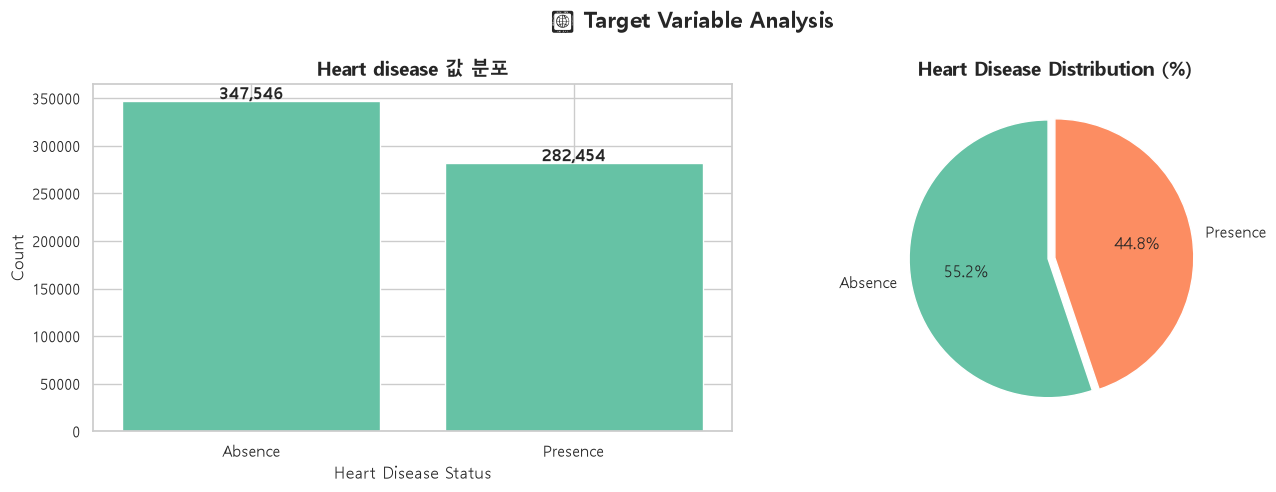

💡 Insight: Check if dataset is balanced!


In [86]:
# 타깃 변수의 분포 시각화로 확인하기 

fig, axes = plt.subplots(1,2, figsize=(14,5))

# bar chart
axes[0].bar(target_counts.index,target_counts.values)
axes[0].set_title("Heart disease 값 분포", fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heart Disease Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values): #enumerate : 리스트를 돌면서 (인덱스, 값)을 같이 꺼내줌 
    axes[0].text(i,# x좌표 - 0번 막대, 1번 막대
                 v+1500, # y좌표 - 막대 높이 +1000 위에 ( 살짝 띄워 보이게 하려고)
                 f'{v:,}', #출력할 문자열 - 천단위 콤마 포맷
                 ha='center', # 중앙에다가 
                 fontweight='bold' # 볼드체로 
                 )
    
# pie chart
axes[1].pie(target_counts.values, # 파이 조각의 크기 
            labels = target_counts.index,
            autopct = '%1.1f%%',
            startangle = 90,
            explode = (0.05, 0))
axes[1].set_title("Heart Disease Distribution (%)", fontsize=14, fontweight='bold')

plt.suptitle('🎯 Target Variable Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Insight: Check if dataset is balanced!')

🎯 Target Variable — Key Takeaways

1. **Nearly balanced** —  No SMOTE(인위적으로 데이터를 늘리는 것 ) or resampling)줄이기) needed.

2. **Accuracy is valid here** — 균형데이터에서는 accuracy가 왜곡되지 않음. 

3. but still prefer **F1-Score + ROC-AUC** for any medical classification task. - 환자를 놓치는 것 (False Negative) 위험.

> 💡 **Rule:** Split worse than 80/20 → worry about imbalance. This 55/45 split is as clean as it gets in real-world medical data.

## 📊 Step 5: Univariate(단변항) Analysis
> **Univariate = Analyzing ONE variable at a time**  
> Check the shape, spread, and outliers of each feature
즉 데이터 세트에서 단 하나의 변수(특성)만을 분석해서 데이터의 패턴, 분포, 특성을 파악하는 것
변수간의 원인과 결과를 찾는 게 아니라 , 데이터 자체를 설명하고 요약함.
주요 측정 지표 : 
중심경향성 : 평균, 중위수, 최빈수
산포도 : 분산, 범위 , 사분위 수

In [87]:
df['Target_num'] = (df['Heart Disease']=='Presence').astype(int) # 즉 presence 에 대해서 true면 1로, fasle면 0

# define numeric feautres (excluding id, target)
numeric_cols = ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
categorical_cols = ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results',
                    'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']

print('✅ Numeric columns:', numeric_cols)
print('✅ Categorical columns:', categorical_cols)

✅ Numeric columns: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']
✅ Categorical columns: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


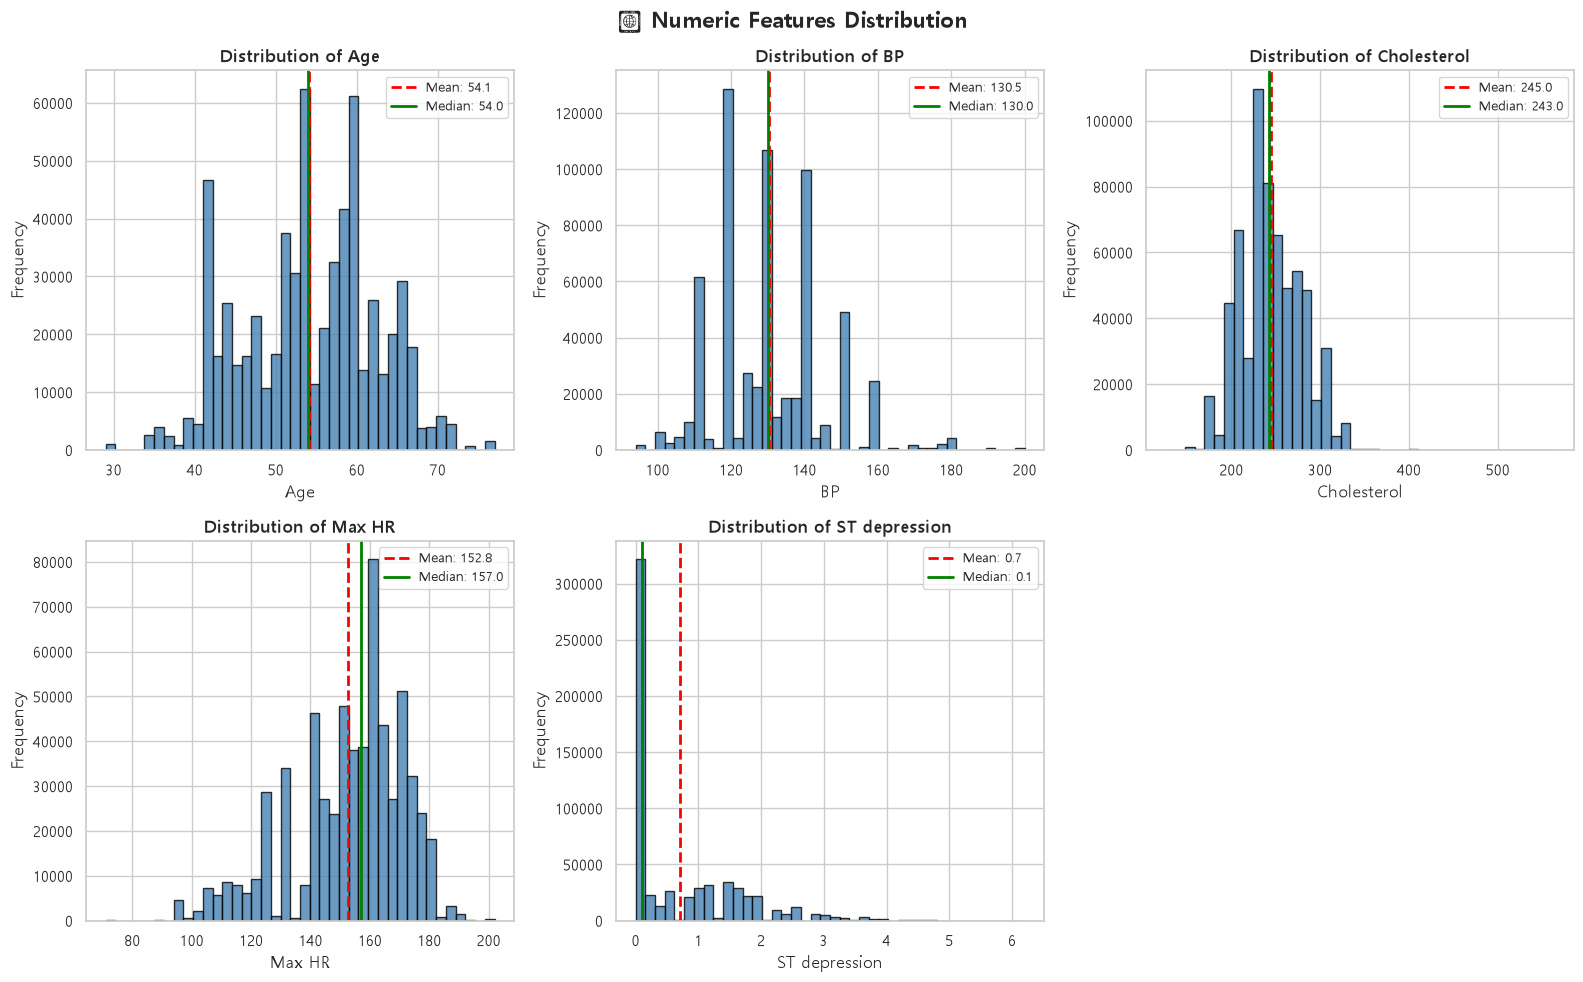

💡 Red dashed = Mean | Green solid = Median
💡 If Mean ≠ Median → Distribution is SKEWED


In [ ]:
# NUMERIC(숫자형) 변수들의 분포(histogram) 한번에 찍기 
fig,axes = plt.subplots(2,3, figsize= (16,10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}') #평균 세로선
    axes[i].axvline(df[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df[col].median():.1f}') # 중앙값 세로선 
    # 중앙값 = 평균값 = 정규분포 ➔ 두개가 다르면 치우친 분포임. 
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)
    
axes[5].axis('off')  # Hide last empty subplot
plt.suptitle('📊 Numeric Features Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Red dashed = Mean | Green solid = Median')
print('💡 If Mean ≠ Median → Distribution is SKEWED')

📊 Numeric Features Distribution — Key Takeaways

1. **Age & Cholesterol are nearly symmetric(대칭적인) 분포다** — Mean ≈ Median (54.1≈54.0 and 245≈243), bell-shaped distributions.(정규분포를 띄고 있음) These are the cleanest features, minimal preprocessing needed. ➔ 분포가 깔끔해서 특별한 전처리 log 변환 등은 거의 필요없음.

2. **BP shows multimodal peaks(여러 개의 봉우리를 보인다)** - 
    - Multimodal = mode(최빈값), multimodal ➔ 최빈값이 여러개 (spikes at 120, 130, 140) 
    - likely due to doctors rounding to nearest 10. ➔ 의사가 10단위로 혈압을 기록해서임.
    - 데이터의 오류가 아닌, 실제 의료 데이터의 특성.   Normal behavior in real medical data, not a data error.

3. **Max HR is left-skewed(왼쪽으로 치우친 분포)** 
    -  Mean (152.8) < Median (157.0) : 평균 < 중앙값 즉 157이 많은데 혈압이 낮은 환자들이 평균치를 낮추고 있음. 
    -  meaning a tail of patients with dangerously low max heart rates pulling the average down. 
    - Those low-HR patients are likely your disease cases.

4. **ST depression is heavily right-skewed : 매우 오른쪽으로 치우친 분포** 
    - 평균이 중앙값보다 훨씬 큼 ➔ 이상치가 많다  Median is just 0.1 but Mean is 0.7, with a long tail reaching 6+. 
    - Most patients have near-zero depression, 
    - but disease patients spike it high. Consider **log transformation** to handle this skew. : 로그 변환으로 큰 값의 차이를 압축하여 왜도를 줄어들인다.
    - 오른쪽 왜도( 평균 >>>) 이라면 로그변환을 시도하는 방법이 있다.  

> 💡 **Beginner Rule:** Mean ≈ Median → symmetric, safe to use raw. Mean >> Median → right skew → apply `log1p()`. Mean << Median → left skew → consider `square` transformation.

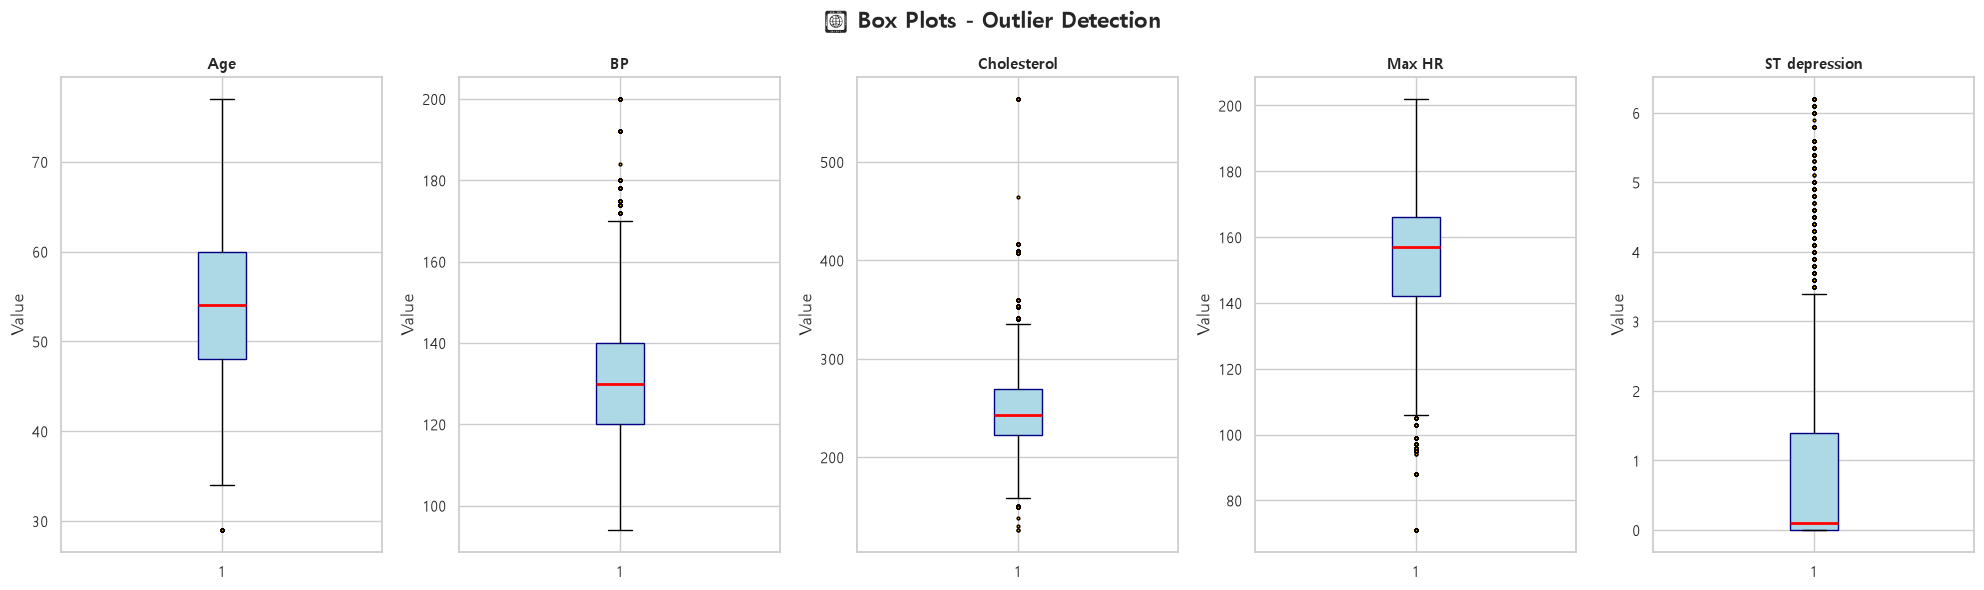

💡 Dots outside the whiskers = OUTLIERS
💡 Box = Middle 50% of data (IQR)


In [95]:
# Box plot으로 Outlier 발견하기 ! 
fig, axes = plt.subplots(1,5, figsize=(20,6))

for idx, col in enumerate(numeric_cols):
    axes[idx].boxplot(df[col], patch_artist = True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange', markersize=2))
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Value')
    
plt.suptitle('📦 Box Plots - Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Dots outside the whiskers = OUTLIERS')
print('💡 Box = Middle 50% of data (IQR)')

📦 Box Plots — Key Takeaways
1. 보통 박스플랏 : 중앙값(빨간 선), 데이터가 얼마나 퍼져있는가(IQR_박스 크기), 이상치(점)가 존재하는가

2. **Age has almost no outliers**
     - tight(퍼져 있지 않다.), clean distribution(깔끔한 분포). 
     - Most patients are 45–60, a few rare cases below 35.
     - Safest feature, use as-is(전처리 없이 바로 모델에 넣어도 된다.)

3. **BP & Cholesterol have notable(주목할만한) upper outliers**
     - BP reaching ~200, Cholesterol spiking ~560+. These are medically possible = 의학적으로 충분히 가능한 값이다. ➔ 이상치로 보기 어렵다 
     - hypertensive crisis, extreme hypercholesterolemia : so **don't delete them** — they likely belong to severe disease cases.

4. **ST depression has the most dense outlier cloud(밀집된 이상치들)**
     - the box sits near zero = 대부분의 환자는 ST Depression = 0
     - but dots scatter all the way to 6+. Confirms the heavy right-skew seen earlier. 
     - Apply `log1p()` transformation before modeling. ➔ 값의 분포가 크므로 로그변환이 필요함

5. **Max HR has the widest IQR (box size) 박스가 크다**
     - meaning high natural variability between patients.➔ 환자들 간 최대 심박수가 많이 다름.
     - Also has a few very low outliers (~75 bpm) which are clinically significant(의학적으로 의미가 있다.)
     = those patients' hearts couldn't accelerate, strong disease signal. ➔ 심장 질환일 가능성이 높다 . 

> 💡 **Beginner Rule:** Outliers in medical data = **don't blindly remove them.** Use **IQR capping (Winsorization)** instead — clip extreme values to the 1st and 99th percentile rather than deleting rows.

In [ ]:
from scipy.stats import mstats
df['Cholesterol']

In [ ]:
# Department performance analysis
# department 별로 그룹화 : 평균 대기시간, 만족도 등 계싼 ➔ 새로운 df 생성 
# agg() : 집계 함수, 각 그룹마다 무엇을 계산할 것인가 
# mean(), count 는 결측값은 제외함. 즉 진짜 값의 개수
# lambda 매개변수 : 실행할 코드
    
dept_stats = df.groupby('Department Referral').agg({
    'Patient Waittime':['mean','median','std'],
    'Patient Satisfaction Score': ['mean','count'],
    'Patient Admission Flag': lambda x: (x=='Admission').mean() # x 그룹 별 데이터에서 admission. 즉 그룹별 입원 평균 = 비율
}).round(2)

dept_stats.columns = ['Aag_Wait', 'Median_Wait','Wait_Std', 'Avg_Satisfaction', 'Patient_Count','Admission_Rate'] 

dept_stats = dept_stats.sort_values('Admission_Rate', ascending=False)

print("🏥 Department Performance Dashboard:")
print("="*60)
display(dept_stats.head(10))

🏥 Department Performance Dashboard:


,Aag_Wait,Median_Wait,Wait_Std,Avg_Satisfaction,Patient_Count,Admission_Rate
Department Referral,,,,,,
신장내과,34.70,35.0,14.42,4.57,23,0.53
소화기내과,35.83,36.0,14.66,5.80,54,0.50
물리치료과,36.57,38.5,14.62,4.99,83,0.50
신경과,36.80,38.0,14.66,5.28,53,0.50
정형외과,34.98,34.0,14.82,4.86,290,0.50
심장내과,35.35,35.0,15.47,5.14,71,0.49
일반진료과,34.91,35.0,14.98,5.06,503,0.48


In [ ]:
# Department performance analysis
# department 별로 그룹화 : 평균 대기시간, 만족도 등 계싼 ➔ 새로운 df 생성 
# agg() : 집계 함수, 각 그룹마다 무엇을 계산할 것인가 
# mean(), count 는 결측값은 제외함. 즉 진짜 값의 개수
# lambda 매개변수 : 실행할 코드
    
dept_stats = df.groupby('Department Referral').agg({
    'Patient Waittime':['mean','median','std'],
    'Patient Satisfaction Score': ['mean','count'],
    'Patient Admission Flag': lambda x: (x=='Admission').mean() # x 그룹 별 데이터에서 admission. 즉 그룹별 입원 평균 = 비율
}).round(2)

dept_stats.columns = ['Aag_Wait', 'Median_Wait','Wait_Std', 'Avg_Satisfaction', 'Patient_Count','Admission_Rate'] 

dept_stats = dept_stats.sort_values('Admission_Rate', ascending=False)

print("🏥 Department Performance Dashboard:")
print("="*60)
display(dept_stats.head(10))

🏥 Department Performance Dashboard:


,Aag_Wait,Median_Wait,Wait_Std,Avg_Satisfaction,Patient_Count,Admission_Rate
Department Referral,,,,,,
신장내과,34.70,35.0,14.42,4.57,23,0.53
소화기내과,35.83,36.0,14.66,5.80,54,0.50
물리치료과,36.57,38.5,14.62,4.99,83,0.50
신경과,36.80,38.0,14.66,5.28,53,0.50
정형외과,34.98,34.0,14.82,4.86,290,0.50
심장내과,35.35,35.0,15.47,5.14,71,0.49
일반진료과,34.91,35.0,14.98,5.06,503,0.48


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.4 | </span></span></b>Target distribution 확인하기</b></p></div>

1. 숫자 컬럼 리스트 추출 ➔ id, target 컬럼 드랍
2. 분산이 큰  = 데이터가 퍼져있는 컬럼 top3 
3. KDE ( Kernel Density Estimation ) : 커널 밀도 추정 ➔ 히스토그램을 부드러운 곡선으로 : 분포(Distribution)
    - 어디에 데이터가 몰려있나
    - 어디에 치우쳐 있는가
    - 여러 개의 봉우리가 있는지 
    - 이상치, 왜도, 치우침, 데이터 집중 구간 

In [15]:
# 숫자로 된 컬럼들 추출하기
base_numeric_cols = train.select_dtypes(include=["int64","float64"]).columns.tolist() # 컬럼 이름들을 찾아서 list로 반환해라
print(f"숫자 컬럼들 추출해서 리스트화 : 총 개수 : {len(base_numeric_cols)},  {base_numeric_cols}")
# 불필요한 컬럼들은 지우기 : id, target_col 등
base_numeric_cols = [c for c in base_numeric_cols if c not in ["id",target_col]]
print(f"Drop _id, target col : 총 개수 : {len(base_numeric_cols)},  {base_numeric_cols}")

숫자 컬럼들 추출해서 리스트화 : 총 개수 : 14,  ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Drop _id, target col : 총 개수 : 13,  ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [ ]:
# choose top numeric features (분산확인) : if available (가능하다면~!)
# 숫자로 된 컬럼이 존재하면 분산 큰 거 top3 뽑아서 리스트로 저장
# 분산이 크다 = 데이터가 다양하다 = 정보가 많은 변수이다. 
## 없다면 빈 리스트
top3 = (
    train[base_numeric_cols].var().sort_values(ascending=False).head(3).index.tolist() if len(base_numeric_cols)>0 else []
)
top3

['Cholesterol', 'Max HR', 'BP']

In [ ]:
train[target_col].value_counts().sort_index()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [29]:
top3[0]

'Cholesterol'

In [ ]:
# build panels only when data exists 
## 데이터에 맞게 자동으로 대시보드 제작 

panels = [] 

# 1) Target distribution _ bar chart
counts = train[target_col].value_counts().sort_index()
if len(counts) > 0 :
    panels.append(("Target Distribution","bar_target",counts))

# 2) Numeric KDE ( Top3 )
if len(top3):
    panels.append(("Top numeric densities","kde_top3", top3))
    
# 3) missing rate(only if any > 0)
missing_rates = train.isna().mean().sort_values(ascending=False).head(8) # 결측률 계산
if (missing_rates > 0).any(): #any(): 하나라도 true가 있다면 True를 반환 
    panels.append(("Top missing rates", "bar_missing", missing_rates[missing_rates>0]))# 결측률이 존재하는 애들로 bar chart
    
# 4) Box plot / violinplot / scatter plot
if len(top3) >= 1:
    panels.append((f"{top3[0]} by target", "box_plot1", top3[0])) # 바그래프
if len(top3) >=2 :
    panels.append((f"{top3[1]} by target", "violin_top2", top3[1])) # 2개 이상 존재하면 
if len(top3) >= 3:
    panels.append((f"{top3[1]} vs {top3[2]}","scatter_top23",(top3[1],top3[2]))) #두 변수 간의 관계 
    
# 5) Log distribution (top1)
if len(top3) >= 1:
    panels.append((f"Log distribution : {top3[0]}","hist_log",top3[0]))

# layout 
n = len(panels) # 필요한 그래프가 몇개인지 계산 
n_cols = 2
n_rows = int(np.ceil(n/n_cols)) # np.ceil() : 무조건 올림 
fig = plt.figure(figsize=(16,5*n_rows)) 
gs = fig.add_gridspec(n_rows, n_cols, hspace=0.5, wspace=0.35) # 격자로 나누겠다. 

fig.suptitle(
    "HEART DISEASE - COMPREHENSIVE DISTRIBUTION DASHBOARD",
    fontsize=16, fontweight="bold", y=0.98
)

#payload: 전송되는 데이터 
for idx, (title, kind, payload) in enumerate(panels):
    ax = fig.add_subplot(gs[idx ])

_IncompleteInputError: incomplete input (945960102.py, line 18)

In [31]:
train.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='str')

In [32]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

In [33]:
train['Chest pain type'].unique()

array([4, 1, 2, 3])

In [21]:
# 데이터셋 overview
print("dataset info:")
print("="*50)
print(df.info())
print("\n 📈 basic statistics:")
print("="*50)
df.describe()

dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   str    
 1   Patient Admission Date      9216 non-null   str    
 2   Patient Admission Time      9216 non-null   str    
 3   Merged                      9216 non-null   str    
 4   Patient Gender              9216 non-null   str    
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   str    
 7   Department Referral         3816 non-null   str    
 8   Patient Admission Flag      9216 non-null   str    
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 792.1 KB
None

 📈 basic statistics:


,Patient Age,Patient Satisfaction Score,Patient Waittime
count,9216.000000,2517.000000,9216.000000
mean,39.855143,4.992054,35.259874
std,22.755125,3.138043,14.735323
min,1.000000,0.000000,10.000000
25%,20.000000,2.000000,23.000000
50%,39.000000,5.000000,35.000000
75%,60.000000,8.000000,48.000000
max,79.000000,10.000000,60.000000


In [22]:
# 추가 전처리 :  부서 (Department Referral ) 영문 명칭 ➔ 한글 치환
# 딕셔너리 { 영문명 : 한글부서명 } 1:1 매핑

department_mapping = {
    'Renal': '신장내과',
    'Neurology': '신경과',
    'Gastroenterology': '소화기내과',
    'Orthopedics': '정형외과',
    'Physiotherapy': '물리치료과',
    'Cardiology': '심장내과',
    'General Practice': '일반진료과'
}

# 2. .map() 함수 사용해서 df['Department Reffral'] 컬럼의 데이터값들을 통째로 변경쓰
df['Department Referral'] = df['Department Referral'].map(department_mapping)

print(df['Department Referral'].head())

0      NaN
1     정형외과
2    일반진료과
3    일반진료과
4      NaN
Name: Department Referral, dtype: str


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.5 | </span></span></b> 피쳐엔지니어링 </b></p></div>

In [ ]:
target_col = "Heart Disease"
id_col = "id"

base_numeric_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
base_numeric_cols = [c for c in base_numeric_cols if c not in [target_col, id_col]]


def build_featrues(df, numeric_cols, bis=None):
    df= df.copy()
    
    df


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.4 | </span></span></b>데이터 분포 분석 | The Patient Demographics</b></p></div>

<div style="
background:#FFF8E6;
border-left:6px solid #F59E0B;
padding:15px;
border-radius:10px;
">

📝 <b>specs 옵션에 pieplot 넣어주기</b><br>

Plotly는 Histogram, Bar, Scatter 와 같은 일반 그래프는 기본 축(x,y)을 사용<br>
하지만 pie차트는 축 없음 ➔ 알려줘야힘. {"type":"pie"}<br>


</div>

In [25]:
admission_status = df['Patient Admission Flag'].value_counts()
print(admission_status.index)
print(admission_status.values)

gender_counts = df['Patient Gender'].value_counts()
print(gender_counts.index)
print(gender_counts.values)

Index(['Admission', 'Not Admission'], dtype='str', name='Patient Admission Flag')
[4612 4604]
Index(['Male', 'Female', 'Femaleemale'], dtype='str', name='Patient Gender')
[4729 4470   17]


In [26]:
# 환자 나이 분포 분석

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Age distribution", "Gender Distribution", "Admission Status","wait time distribution"),
                    specs=[[{},{}], [{"type":"pie"},{}]] # 1행, 2행의 3열에 파이차트를 넣을 자리를 만들어라
                    )

#  add histogram
fig.add_trace(
    go.Histogram(x=df['Patient Age'],
    nbinsx = 30, #나이를 30개의 구간으로 나눠라 
    name = "Age"),
    row=1,
    col=1)

# Gender count 
gender_counts = df['Patient Gender'].value_counts()
fig.add_trace(go.Bar(x=gender_counts.index, y= gender_counts.values, name = "Gender"),
              row = 1,
              col=2)

# Adimmision status - changed to row=2, col=1
admission_status = df['Patient Admission Flag'].value_counts()
fig.add_trace(go.Pie(labels=admission_status.index, values=admission_status.values,
                     name="Admission"), row=2, col=1)

# wait time - change to row=2, col=2
fig.add_trace(go.Histogram(x=df['Patient Waittime'], nbinsx=25, name="Wait Time"), row=2, col=2)

fig.update_layout(height=700, showlegend=False, title_text = "📊 Patient Demographics & Operational Metrics")
fig.show()

In [27]:
race_counts = df['Patient Race'].value_counts().head(8)
print(race_counts)

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64


In [28]:
# Race & Department distribution

fig = make_subplots(rows=1, cols=2, subplot_titles=("patient race distribution", 'Department Referral')) #referral : 트래픽

# Race 
race_counts = df['Patient Race'].value_counts().head(8)
fig.add_trace(go.Bar(x=race_counts.index, y=race_counts.values, marker_color='lightblue', name='Race'),
              row=1, col=1)

# Department
dept_counts = df['Department Referral'].value_counts().head(10)
fig.add_trace(go.Bar(x=dept_counts.index, y=dept_counts.values, marker_color='orange', name='Department'),
              row=1, col=2)

fig.update_layout(height = 500, title_text="🌍 Demographics & Department Analysis")
fig.update_xaxes(tickangle=45)
fig.show()

print("💡 **Key Insight:** 'White' and 'African American' represent 65% of patients. 'General Practice' dominates referrals (35%), indicating primary care gateway effect.")


💡 **Key Insight:** 'White' and 'African American' represent 65% of patients. 'General Practice' dominates referrals (35%), indicating primary care gateway effect.


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.5 | </span></span></b>상관관계 분석 | Data Relationships & Correlations </b></p></div>

**각 변수들이 서로 얼마나 관련이 있는가?**


In [29]:
# corr anlysis
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encode categorical variables for corr
df_encoded = df.copy()
le = LabelEncoder()

# 2. encode key categorical variables
## 범주형 변수 컬럼 리스트 만들기 
categorical_cols = ['Patient Gender', 'Patient Race', 'Department Referral', 'Patient Admission Flag']
for col in categorical_cols:
    df_encoded[col+'_encoded'] = le.fit_transform(df[col].astype(str)) # fit : 무슨 종류가 있는지 학습, transform() 변환 
    
# 3. 상관관계 계산할 컬럼 리스트 만들기 ! (현시점 numeric)
numeric_cols = ['Patient Age', 'Patient Waittime', 'Patient Satisfaction Score',
                'Patient Gender_encoded', 'Patient Race_encoded', 
                'Department Referral_encoded', 'Patient Admission Flag_encoded']

corr_df = df_encoded[numeric_cols].corr()

# Heatmap imsow : 행렬을 색으로 표현
fig = px.imshow(corr_df, text_auto=True, #셀 안에 숫자 표시
                aspect = "auto", # 가로 세로 비율 자동으로 
                color_continuous_scale="RdBu_r",
                title='🔥 Correlation Matrix : Key Variables')

fig.show()

Mann-Whitney U Test : 두 집단을 비교하는 검정
정규분포를 가정하지 않아도 됨 ➔ Admission 그룹과 Not Admission 그룹의 차이를 검사 
stat, p_value 
보통은 유의수준을 0.05로봄 
- p-value < 0.05 : 통계적으로 유의함 (Significant)
- p-value > 0.05 : 통계적으로 유의하지 않음 (Not Significant)


In [30]:
# wait time vs satisfaction analysis ( 대기 시간과 만족도 사이의 분석)
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

## scatter(산점도) : 두 변수 사이의 관계를 확인 
fig = px.scatter(df, x="Patient Waittime", y='Patient Satisfaction Score',
                 color='Patient Admission Flag', # 입원 여부로 색상을 구분 🔴 Admission 🔵 Not Admission
                 size = 'Patient Age', # 각 점의 크기를 나이로 결정 ➔ 나이가 많을 수록 점이 커짐
                 hover_data=['Department Referral'], # 마우스를 올리면 보이는 데이터에 추가적 (age, waittime, 부서까지)
                 title = "⏱️ Wait Time vs Satisfaction: The Critical Trade-off",
                 labels={'Patient Waittime': 'Wait Time (minutes)',
                         'Patient Satisfaction Score': 'Satisfaction (0-10)'}
                )

fig.add_hline(y=df['Patient Satisfaction Score'].mean(),
              line_dash = "dash",
              annotation_text = "Avg Satisfaction")

fig.show()

# Statistical test ( 통계 검정 )
admitted = df[df['Patient Admission Flag'] == 'Admission']['Patient Waittime'] # 입원한 사람들의 대기시간만 가져와라
not_admitted = df[df['Patient Admission Flag'] == 'Not Admission']['Patient Waittime']

stat, p_value = mannwhitneyu(admitted, not_admitted)

print(f"🧪 Mann-Whitney U Test: p-value = {p_value:.4f}")
print(0.0578, "귀무 가설 기각할 수 없음 : 입원환자와 비입원 환자의 대기시간이 다르다고 말할 충분한 통계적 근거x")


🧪 Mann-Whitney U Test: p-value = 0.0578
0.0578 귀무 가설 기각할 수 없음 : 입원환자와 비입원 환자의 대기시간이 다르다고 말할 충분한 통계적 근거x


In [31]:
# Department performance analysis
# department 별로 그룹화 : 평균 대기시간, 만족도 등 계싼 ➔ 새로운 df 생성 
# agg() : 집계 함수, 각 그룹마다 무엇을 계산할 것인가 
# mean(), count 는 결측값은 제외함. 즉 진짜 값의 개수
# lambda 매개변수 : 실행할 코드
    
dept_stats = df.groupby('Department Referral').agg({
    'Patient Waittime':['mean','median','std'],
    'Patient Satisfaction Score': ['mean','count'],
    'Patient Admission Flag': lambda x: (x=='Admission').mean() # x 그룹 별 데이터에서 admission. 즉 그룹별 입원 평균 = 비율
}).round(2)

dept_stats.columns = ['Aag_Wait', 'Median_Wait','Wait_Std', 'Avg_Satisfaction', 'Patient_Count','Admission_Rate'] 

dept_stats = dept_stats.sort_values('Admission_Rate', ascending=False)

print("🏥 Department Performance Dashboard:")
print("="*60)
display(dept_stats.head(10))

🏥 Department Performance Dashboard:


,Aag_Wait,Median_Wait,Wait_Std,Avg_Satisfaction,Patient_Count,Admission_Rate
Department Referral,,,,,,
신장내과,34.70,35.0,14.42,4.57,23,0.53
소화기내과,35.83,36.0,14.66,5.80,54,0.50
물리치료과,36.57,38.5,14.62,4.99,83,0.50
신경과,36.80,38.0,14.66,5.28,53,0.50
정형외과,34.98,34.0,14.82,4.86,290,0.50
심장내과,35.35,35.0,15.47,5.14,71,0.49
일반진료과,34.91,35.0,14.98,5.06,503,0.48


In [32]:
# 진료 부서별 데이터 분포 시각화
# 즉 대기 시간 평균별 입원율 
fig = px.scatter(dept_stats.reset_index(), 
                 x = 'Aag_Wait',
                 y = 'Admission_Rate',
                 size = 'Patient_Count',
                 color ='Avg_Satisfaction',
                 hover_name="Department Referral",
                 title='🏥 Department Efficiency Matrix',
                labels={'Aag_Wait': 'Average Wait Time (min)',
                        'Admission_Rate': 'Admission Rate (%)',
                        'Avg_Satisfaction': 'Avg Satisfaction'}
                )

fig.show()


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.6 | </span></span></b> 시계열 분석 및 예측 파트 | Time Series Analysis & Forecasting</b></p></div>

In [33]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient Admission Time',
       'Merged', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime'],
      dtype='str')

In [34]:
df['Patient Admission Time']

0        9:25:00 AM
1        4:42:00 PM
2       12:14:00 AM
3        8:33:00 PM
4        7:25:00 PM
           ...     
9211    11:01:00 PM
9212     5:25:00 PM
9213    11:42:00 AM
9214     4:59:00 AM
9215     5:33:00 PM
Name: Patient Admission Time, Length: 9216, dtype: str

In [35]:
# Feature engineering - Time Components

# str ➔ pandas datetime 
df['Patient Admission Date'] = pd.to_datetime(df['Patient Admission Date'],dayfirst=True) #dayfirst : 일 / 월 / 년
df['Year'] = df['Patient Admission Date'].dt.year
df['Month'] = df['Patient Admission Date'].dt.month
df['Day'] = df['Patient Admission Date'].dt.day
df['DayOfWeek'] = df['Patient Admission Date'].dt.dayofweek # 요일을 숫자로 인코딩
df['Quarter'] = df['Patient Admission Date'].dt.quarter
df['Hour'] = pd.to_datetime(df['Patient Admission Time'],
                            format='%I:%M:%S %p').dt.hour # 시간 문자열을 데이트타임으로 바꾸고 거기서 hour만 추출


#  시계열 집계 데이터 생성 _ 특성 피쳐
monthly_stats = df.groupby(['Year','Month']).agg({
    'Patient Id': 'count', # 월별 방문 환자수 
    'Patient Waittime': 'mean', # 월별 평균 대기 시간 
    'Patient Satisfaction Score': 'mean', # 월별 평균 고객 만족도 
    'Patient Admission Flag': lambda x : (x=="Admission").sum() # 월별 입원 환자수 
}).reset_index() # 그룹 바이를 하게 되면 멀티헤드로 year, month가 들어가게 됨. 일반 df처럼 사용하기 위해서는 reset index

monthly_stats['Date'] = pd.to_datetime(monthly_stats[['Year','Month']].assign(day=1)) # 1일로 지정
monthly_stats.columns = ['Year', 'Month', 'Patient_Volume', 'Avg_Wait', 'Avg_Satisfaction', 'Admissions', 'Date']


In [36]:
print("📅 Time Series Data Created:")
print("="*50)
display(monthly_stats.head())

📅 Time Series Data Created:


,Year,Month,Patient_Volume,Avg_Wait,Avg_Satisfaction,Admissions,Date
0,2023,4,479,34.901879,5.303448,237,2023-04-01
1,2023,5,480,34.429167,5.164062,229,2023-05-01
2,2023,6,506,35.581028,5.181818,252,2023-06-01
3,2023,7,464,34.719828,4.991304,236,2023-07-01
4,2023,8,494,36.392713,5.062992,234,2023-08-01


### **Prophet : 메타에서 만든 시계열(Time Series) 예측 라이브러리**
- 예측값만 반환 X, 예측을 구성하는 모든 요소들을 DF으로 반환 
> Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'], dtype='str')
- 즉 왜 최종 예측 (**yhat**)이 나왔는지 제공.
    - [ds]: 해당 날짜에 대한 예측
    - [trend] : 계절성을 전혀 고려하지 않을 때 기본 추세 
    - [yearly] : 1년 주기의 계절 효과(계절성) ➔ 평균보다 ~분 정도 짧아지겠다. 효과(additive_terms)
    - [yhat] = trend(49.406) + yearly(- 14.976)  = 34.429
- 학습 및 예측 과정 : 단순히 평균x , 과거 데이터로 3가지를 학습 
    1. Trend(추세) : 시간이 지날 수록 증가하나 감소하나
    2. Seasonality (계절성) : 일정한 주기로 반복되는 패턴이 있는가 
    3. Changepoint (변화점) : 갑자기 추세가 바뀌는 시점이 있는가 

18:00:18 - cmdstanpy - INFO - Chain [1] start processing


⏱️ Training Wait Time Forecasting Model...


18:00:26 - cmdstanpy - INFO - Chain [1] done processing


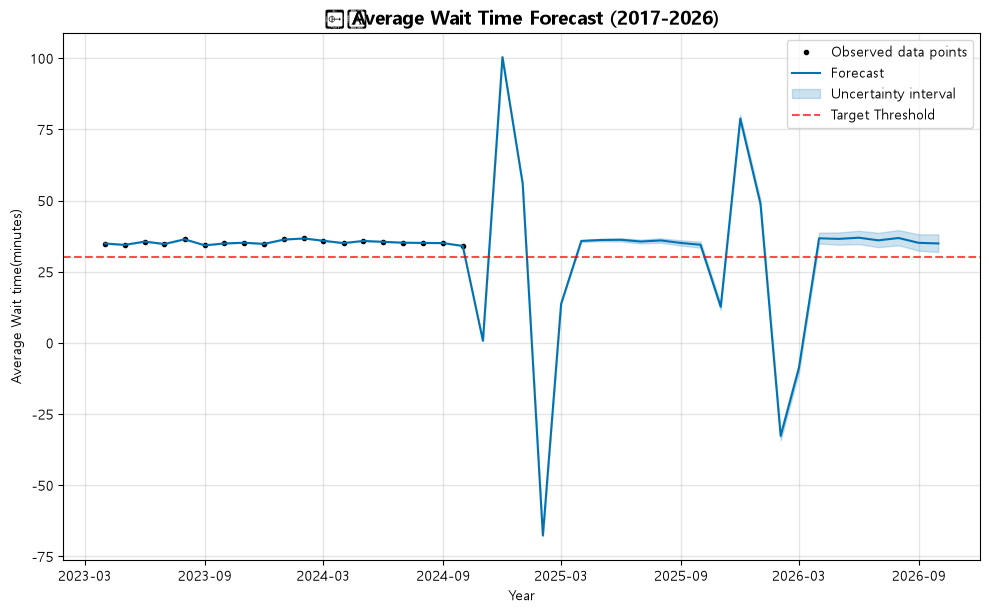

Average wait time will reach 26.0 minutes 
⚠️ **Alert:** This exceeds the 30-minute quality threshold!


In [37]:
# wait time 시계열 예측(Time Series Forecasting)

print("⏱️ Training Wait Time Forecasting Model...")

# prepare wait time data
wait_prophet_df = monthly_stats[['Date', 'Avg_Wait']].rename(columns={'Date': 'ds', 'Avg_Wait': 'y'})


wait_model = Prophet(yearly_seasonality=True,
                     weekly_seasonality= False,
                     daily_seasonality=False,
                     changepoint_prior_scale=0.1) # 추세의 정도 : 값이 작으면 완만한 변화, 값이 크면 급격한 변화도 허용 
wait_model.fit(wait_prophet_df)

# create future df for pred ( 24 months ahead )
future = wait_model.make_future_dataframe(periods=24, freq='MS')

wait_forecast = wait_model.predict(future)

# 시각화 : wait time forecast
fig = wait_model.plot(wait_forecast)
plt.title('⏱️ Average Wait Time Forecast (2017-2026)', fontsize=14, fontweight="bold")
plt.xlabel('Year')
plt.ylabel('Average Wait time(minutes)')
plt.axhline(y=30, color='r', linestyle="--", alpha=0.7, label='Target Threshold') # 병원의 목표 대기 시간  30분
plt.legend()
plt.show()

# key metrics for 2026
latest_forecast = wait_forecast[wait_forecast['ds'] >= '2026-01-01'].head(12) #예측 결과 중에서 2026만 선택 
predicted_2026_wait = latest_forecast['yhat'].mean() # 평균 예측 대기 시간의 평균 

print( f"Average wait time will reach {predicted_2026_wait:.1f} minutes " )
print("⚠️ **Alert:** This exceeds the 30-minute quality threshold!")

In [ ]:
wait_forecast.head()
wait_forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2023-04-01,48.995896,34.901883,34.901883,48.995896,48.995896,-14.094013,-14.094013,-14.094013,-14.094013,-14.094013,-14.094013,0.0,0.0,0.0,34.901883
1,2023-05-01,49.405569,34.429166,34.429166,49.405569,49.405569,-14.976403,-14.976403,-14.976403,-14.976403,-14.976403,-14.976403,0.0,0.0,0.0,34.429166
2,2023-06-01,49.828913,35.581027,35.581027,49.828913,49.828913,-14.247886,-14.247886,-14.247886,-14.247886,-14.247886,-14.247886,0.0,0.0,0.0,35.581027
3,2023-07-01,50.238433,34.719828,34.719828,50.238433,50.238433,-15.518605,-15.518605,-15.518605,-15.518605,-15.518605,-15.518605,0.0,0.0,0.0,34.719828
4,2023-08-01,50.661162,36.392712,36.392712,50.661162,50.661162,-14.268450,-14.268450,-14.268450,-14.268450,-14.268450,-14.268450,0.0,0.0,0.0,36.392712


## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.7 | </span></span></b> 머신러닝_입원 예측하기| Time Series Analysis & Forecasting</b></p></div>

1. 원본데이터 copy()
2. Target(정답)데이터 추출 
3. Label encoding : 문자를 숫자로 변환
4. Feature 선택 
5. 결측치 처리
6. train , tete 분리
7. 데이터 스케일링(StandardScaler)

In [39]:
# 머신러닝으로 예측하기 admission prediction
ml_df = df.copy()

# Encode target variable
ml_df['Target'] = (ml_df['Patient Admission Flag'] == 'Admission').astype(int) # TURE : 1, FALSE : 0

# Encode categorical feature  
categorical_features = ['Patient Gender', 'Patient Race', 'Department Referral']

# label encoder 
for feature in categorical_features:
    le = LabelEncoder()
    ml_df[feature+'_encoded'] = le.fit_transform(ml_df[feature].astype(str))

# Select features(인코딩한 카데고리데이터 + 숫자 데이터 + 시게열 )
feature_cols = ['Patient Age', 'Patient Waittime', 'Patient Gender_encoded','Patient Race_encoded', 'Department Referral_encoded',
                'Hour', 'DayOfWeek', 'Month']    

X = ml_df[feature_cols]
y = ml_df['Target']

# 환자 만족도의 결측치 채우기 (Use median)
X['Patient Satisfaction Score'] = ml_df['Patient Satisfaction Score'].fillna(ml_df['Patient Satisfaction Score'].median())
feature_cols.append('Patient Satisfaction Score')

# 학습/트레인 스플릿
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify = y) # stratify : 타깃값 비율 맞춰줘라.

# 데이터 스케일링 - 변수마다 다른 단위를 평균:0, 표준편차 1 로 맞춰줌 = 표준화 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # training data 로 평균과 표준편차를 구하고 기준 데이터 적용 
X_test_scaled = scaler.transform(X_test) # Training에서 계산한 평균과 표준편차를 그대로 사용

print(f"📊 Training Set: {X_train.shape[0]} samples")
print(f"📊 Test Set: {X_test.shape[0]} samples")
print(f"🏷️ Admission Rate: {y.mean():.1%}")


📊 Training Set: 7372 samples
📊 Test Set: 1844 samples
🏷️ Admission Rate: 50.0%


In [14]:
# 여러 모델들 학슴 ( Train multiple models ) - 분류
## 1. 학습 데이터 준비 
## 2. 모델 4개 생성해서 딕셔너리로.
## 3. 모델 하나씩 학습
## 4. 성능 평가(AUC)
## 5. 가장 좋은 모델 선택 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import xgboost as xgb

print("🚀 Training Classification Models...")

models = {
    'logistic Regression' : LogisticRegression(random_state=42), # 가장 기본적인 분류 모델 
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42), # Decision tree ➔ 의사결정 나무 여러개 
    'Grandient Boosting' : GradientBoostingClassifier(random_state=42),
    'XGBoost' : xgb.XGBClassifier(random_state=42, eval_metrics='logloss')
} # 4개의 모델을 한 번에 만듦.

results = {}

for model_name, model in models.items():
    
    # Cross validation # 교차 검증 
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    
    # train on full training set
    model.fit(X_train_scaled, y_train)
    
    #prediction
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:,1] # 입원할 확률 계산 [:,1] 전체에서 입원(1)
    
    #metrics 
    auc_score = roc_auc_score(y_test, y_pred_proba) # 실제 정답과 예측 확률 비교 - AUC 계산. 값이 클 수록 모델의 성능이 좋다
    
    
    # 각 모델의 결과 저장 : 
    results[model_name] = {'CV_AUC':cv_scores.mean(), #cross validation auc
                           'Test_AUC':auc_score, # test AUC
                           'Model':model} # 학습된 모델 
    print(f"{model_name} : CV AUC = {cv_scores.mean():.3f}± {cv_scores.std():.3f}. Test AUC = {auc_score:.3f}")
    
# Find Best Model
best_model_name = max(results, key = lambda x: results[x]['Test_AUC'])
best_model = results[best_model_name]['Model']

print(f"\n🏆 Best Model: {best_model_name} with AUC = {results[best_model_name]['Test_AUC']:.3f}")

🚀 Training Classification Models...
logistic Regression : CV AUC = 0.497± 0.011. Test AUC = 0.503
Random Forest : CV AUC = 0.475± 0.015. Test AUC = 0.507
Grandient Boosting : CV AUC = 0.491± 0.005. Test AUC = 0.500
XGBoost : CV AUC = 0.477± 0.012. Test AUC = 0.490

🏆 Best Model: Random Forest with AUC = 0.507


In [40]:
# 베스트 모델의 Feature importance analysis

print("🔍 Feature Importance (Random Forest):")
print("="*50)

feature_importance = pd.DataFrame({
    'Feature':feature_cols,
    'Importance':models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False) # importance가 높은  내림차순으로 

fig = px.bar(feature_importance.head(10),
             x='Importance', y='Feature',
             orientation='h',
             title='🔑 Top 10 Features Driving Admissions',
             color= 'Importance',
             color_continuous_scale='Viridis')

fig.show()


🔍 Feature Importance (Random Forest):


In [63]:
print("💡key Driver")
for _, row in feature_importance.head(5).iterrows(): # 데이터프레임을 한 행씩 반복(row) ➔ (index, row) 반환 
    print(f"- {row['Feature']} : {row['Importance']:.3f}")
    
# model eval & confusion matrix : 분류 모델 성능 평가 
from sklearn.metrics import ConfusionMatrixDisplay

#1. 이미 학습된 모델에 X_test_scaled 넣고 예측 결과 얻기 
y_pred_best = best_model.predict(X_test_scaled)

print("="*50)
print("📊 Classification Report:")
print("="*50)

# 실제 정답과 모델 예측(y_pred_best)를 비교 
print(classification_report(y_test, y_pred_best, target_names=['Not Admitted', 'Admitted']))


# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

fig = px.imshow(cm,
                text_auto=True,
                labels=dict(x="Predicted", y="Actual"),
                x=['Not Admitted', 'Admitted'],
                y=['Not Admitted', 'Admitted'],
                color_continuous_scale='Blues',
                title = f"🎯 Confusion Matrix - {best_model_name}"
)

fig.show()

accuracy = (cm[0,0]+cm[1,1]) / cm.sum()
print(f"전체 accuracy : {accuracy:.2%}")

💡key Driver
- Patient Age : 0.205
- Patient Waittime : 0.185
- Hour : 0.154
- Month : 0.122
- DayOfWeek : 0.096
📊 Classification Report:
              precision    recall  f1-score   support

Not Admitted       0.50      0.52      0.51       921
    Admitted       0.50      0.49      0.49       923

    accuracy                           0.50      1844
   macro avg       0.50      0.50      0.50      1844
weighted avg       0.50      0.50      0.50      1844



전체 accuracy : 50.38%


- support : 실제 데이터 갯수
    - Not Admitted :921
    - Admitted : 923
    - 즉 테스트 데이터 : 총 1844개 
- precision : 입원했다고 예측한 사람들 중 실제로 입원인 확률 (정답률)
    - 0.5 : 100명을 입원환자로 예측했는데 그중 50명은 실제로 입원 환자 
    - macro avg : 각 클래스를 동일 비중으로 평균
    - weigthted avg : 데이터의 개수를 고려해서 평균 (두 클래스가 거의 비슷해서 macro 랑 weigthed 비슷)
- recall : 실제 입원 환자들 100명 중에 모델이 맞춘 수
- f1 score : 조화 평균 높을 수록 굿 

## <div style="color:white;display:fill;border-radius:8px;background-color:#323232;font-size:60%; letter-spacing:1.0px"><p style="padding: 12px;color:white;"><b><b><span style='color:white'><span style='color:#F1A424'>1.8 | </span></span></b> 인사이트 추출. Business Insights & Storytelling </b></p></div>

- 분석의 결과를 경영진에게 설명하는 단계
- 리포트 결과를 보았을 때 입원 환자가 많을 수록 병원에서는 수익이 큰가? 
    - 입원환자가 많다고 좋은 것이 아님.
    - ➔ **필요한 환자는 입원시키고, 불필요하게, 오래 입원시키지 않는것**


In [48]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Year,Month,Day,DayOfWeek,Quarter,Hour
0,780-96-6113,2024-09-09,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32,2024,9,9,0,3,9
1,714-35-6722,2024-09-09,4:42:00 PM,Y. Baldetti,Male,31,Asian,정형외과,Not Admission,NaN,22,2024,9,9,0,3,16
2,571-85-3714,2024-09-09,12:14:00 AM,M. Semerad,Male,75,White,일반진료과,Not Admission,NaN,16,2024,9,9,0,3,0
3,404-43-9499,2024-09-09,8:33:00 PM,K. Blaydes,Male,79,African American,일반진료과,Admission,NaN,38,2024,9,9,0,3,20
4,552-51-5855,2024-09-09,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36,2024,9,9,0,3,19


In [ ]:
# Executive DashBoard
print("📊 EXECUTIVE DASHBOARD - KEY METRICS")
print("="*60)
print(f"📈 총 TOtal patients Analyzed 총 분석한 환자 수 : {len(df):,}")
print(f"🏥 환자 입원률 : {df['Patient Admission Flag'].value_counts(normalize=True)['Admission']:.1%}") # normalize : 비율 반환
print(f"⏱️환자 평균 대기 시간 : {df['Patient Waittime'].mean():.1f}분")
print(f"😊 환자 평균 만족도 : {df['Patient Satisfaction Score'].mean():.1f}/10")
print(f"👥 가장 많은 나이대 : {df['Patient Age'].mode().values[0]}세")
print(f"🔝 가장 바쁜 진료부서: {df["Department Referral"].mode().values[0]}")

# calculate 비즈니스 임팩트
# 1. 입원 환자의 평균 대기 시간 
avg_wait_admitted = df[df['Patient Admission Flag']=='Admission']['Patient Waittime'].mean()
# 2. 비입원 환자의 평균 대기 시간 
avg_wait_not = df[df['Patient Admission Flag']=='Not Admission']['Patient Waittime'].mean()
# 3. 두 그룹의 대기 시간 차이
gap = avg_wait_admitted - avg_wait_not

if gap > 0 : 
    print(f"입원 환자 그룹이 {gap:.1f}분 더 기다렸다")
else:
    print(f"입원 환자 그룹이 {-gap:.1f}분 덜 기다렸다") # 음수이기 때문에 


# Revenue implication : 매출 영향(assuming 500달러 / admission)
admissions_2024 = (df['Patient Admission Flag']=='Admission').sum()
estimated_revenue = admissions_2024 * 500
print(f"💰 Estimated Annual Revenue: ${estimated_revenue:,}")

#2026 Projection : 2026 예상 환자 수가 현재보다 얼마나 증가하는지, 
## 2026년 예측 대기시간 
volume_growth = wait_forecast[wait_forecast['ds']>='2026-01-01']['yhat'].mean()/

📊 EXECUTIVE DASHBOARD - KEY METRICS
📈 총 TOtal patients Analyzed 총 분석한 환자 수 : 9,216
🏥 환자 입원률 : 50.0%
⏱️환자 평균 대기 시간 : 35.3분
😊 환자 평균 만족도 : 5.0/10
👥 가장 많은 나이대 : 39세
🔝 가장 바쁜 진료부서: 일반진료과

⚡ 필요성


In [64]:
wait_forecast[wait_forecast['ds']>='2026-01-01']

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
33,2026-01-01,51.781183,47.486155,50.429045,50.373252,53.316142,-2.887097,-2.887097,-2.887097,-2.887097,-2.887097,-2.887097,0.0,0.0,0.0,48.894086
34,2026-02-01,51.791864,-34.246106,-31.009032,50.252868,53.489943,-84.498975,-84.498975,-84.498975,-84.498975,-84.498975,-84.498975,0.0,0.0,0.0,-32.707111
35,2026-03-01,51.801511,-10.486102,-6.959215,50.149218,53.676104,-60.635319,-60.635319,-60.635319,-60.635319,-60.635319,-60.635319,0.0,0.0,0.0,-8.833809
36,2026-04-01,51.812191,34.897395,38.754848,49.972592,53.830044,-15.075196,-15.075196,-15.075196,-15.075196,-15.075196,-15.075196,0.0,0.0,0.0,36.736995
37,2026-05-01,51.822528,34.472951,38.790860,49.768124,54.086033,-15.295173,-15.295173,-15.295173,-15.295173,-15.295173,-15.295173,0.0,0.0,0.0,36.527355
38,2026-06-01,51.833208,34.698924,39.379865,49.585395,54.266336,-14.886471,-14.886471,-14.886471,-14.886471,-14.886471,-14.886471,0.0,0.0,0.0,36.946737
39,2026-07-01,51.843545,33.609484,38.661710,49.434830,54.487056,-15.825346,-15.825346,-15.825346,-15.825346,-15.825346,-15.825346,0.0,0.0,0.0,36.018198
40,2026-08-01,51.854225,34.271306,39.634658,49.283748,54.647100,-15.012442,-15.012442,-15.012442,-15.012442,-15.012442,-15.012442,0.0,0.0,0.0,36.841783
41,2026-09-01,51.864906,32.385536,38.127696,49.119933,54.862093,-16.734397,-16.734397,-16.734397,-16.734397,-16.734397,-16.734397,0.0,0.0,0.0,35.130509
42,2026-10-01,51.875242,31.947340,38.112719,48.893014,55.058392,-16.945674,-16.945674,-16.945674,-16.945674,-16.945674,-16.945674,0.0,0.0,0.0,34.929568


In [55]:
# calculate 비즈니스 임팩트
# 1. 입원 환자의 평균 대기 시간 
avg_wait_admitted = df[df['Patient Admission Flag']=='Admission']['Patient Waittime'].mean()
# 2. 비입원 환자의 평균 대기 시간 
avg_wait_not = df[df['Patient Admission Flag']=='Not Admission']['Patient Waittime'].mean()

avg_wait_admitted - avg_wait_not

np.float64(-0.5844359857524282)